# EDA Источника А

---

Этот ноутбук содержит полный разведочный анализ данных для Источника А - набор геоданных о зданиях Санкт-Петербурга.

### Структура анализа:
1. Загрузка и первичный осмотр данных
2. Анализ пропусков
3. Анализ типов объектов - теги
4. Анализ атрибута `area_sq_m` - площадь
5. Анализ адресов и географического покрытия - `gkh_address`
6. Анализ этажности - `gkh_floor_count_min`, `gkh_floor_count_max`
7. Анализ геометрии: валидность, типы, аномалии
8. Пространственный анализ: распределение по городу
9. Выводы и рекомендации по очистке

## 0. Установка зависимостей и импорты

In [3]:
# Установка необходимых пакетов
# !pip install geopandas shapely matplotlib seaborn folium pandas numpy pyproj missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import ast
import re
from collections import Counter
import geopandas as gpd
from shapely import wkt
from shapely.geometry import MultiPolygon, Polygon
from shapely.validation import explain_validity

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False
    print("missingno не установлен - пропустим матрицу пропусков. Установите: pip install missingno")

warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Импорты выполнены успешно")
print(f"   pandas  {pd.__version__}")
print(f"   geopandas {gpd.__version__}")

✅ Импорты выполнены успешно
   pandas  3.0.1
   geopandas 1.1.3


## 1. Загрузка данных

Источник А - CSV-файл с 171 453 записями и 8 полями:

| Поле | Описание |
|------|----------|
| `id` | Идентификатор полигона |
| `title` | Наименование объекта |
| `tags` | Теги (тип объекта) |
| `geometry` | Геометрия в формате WKT |
| `area_sq_m` | Площадь полигона, м² |
| `gkh_address` | Адрес из базы «Реформа ЖКХ» |
| `gkh_floor_count_min` | Минимальная этажность (Реформа ЖКХ) |
| `gkh_floor_count_max` | Максимальная этажность (Реформа ЖКХ) |

In [4]:
# Укажите путь к файлу Источника А
FILE_PATH = 'cup_it_example_src_A.csv'  # Замените на актуальный путь

df = pd.read_csv(FILE_PATH)

print(f"📁 Файл загружен")
print(f"   Строк:   {len(df):,}")
print(f"   Столбцов: {df.shape[1]}")
print(f"\n📋 Колонки: {list(df.columns)}")

📁 Файл загружен
   Строк:   171,454
   Столбцов: 9

📋 Колонки: ['Unnamed: 0', 'id', 'title', 'tags', 'geometry', 'area_sq_m', 'gkh_address', 'gkh_floor_count_min', 'gkh_floor_count_max']


In [5]:
# Первые строки
df.head(10)

,Unnamed: 0,id,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max
0,0,1,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10095 59.82052, 30.10085 59...",84.94625,NaN,NaN,NaN
1,1,2,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10129 59.82047, 30.10124 59...",114.67415,NaN,NaN,NaN
2,2,3,NaN,['жилое здание'],"MULTIPOLYGON (((30.16261 59.86339, 30.1626 59....",122.99800,NaN,NaN,NaN
3,3,4,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18159 59.9857, 30.18167 59....",64.16945,NaN,NaN,NaN
4,4,5,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18162 59.98583, 30.1816 59....",170.71815,NaN,NaN,NaN
5,5,6,NaN,['жилое здание'],"MULTIPOLYGON (((30.18801 59.84758, 30.18814 59...",83.66325,NaN,NaN,NaN
6,6,7,NaN,['жилое здание'],"MULTIPOLYGON (((30.1947 59.85958, 30.19436 59....",42.88710,NaN,NaN,NaN
7,7,8,NaN,['бизнес и услуги'],"MULTIPOLYGON (((30.19994 59.98879, 30.19993 59...",34.80005,NaN,NaN,NaN
8,8,9,NaN,['бизнес и услуги'],"MULTIPOLYGON (((30.20011 59.98876, 30.20012 59...",28.88870,NaN,NaN,NaN
9,9,10,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.20351 60.02996, 30.20356 60...",17.73280,NaN,NaN,NaN


In [6]:
# Типы данных и базовая информация
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171454 entries, 0 to 171453
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           171454 non-null  int64  
 1   id                   171454 non-null  int64  
 2   title                7357 non-null    str    
 3   tags                 171454 non-null  str    
 4   geometry             171454 non-null  str    
 5   area_sq_m            171454 non-null  float64
 6   gkh_address          18239 non-null   str    
 7   gkh_floor_count_min  17293 non-null   float64
 8   gkh_floor_count_max  17632 non-null   float64
dtypes: float64(3), int64(2), str(4)
memory usage: 11.8 MB


In [7]:
# Базовая статистика числовых колонок
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,171454.0,NaN,NaN,NaN,85726.5,49494.650864,0.0,42863.25,85726.5,128589.75,171453.0
id,171454.0,NaN,NaN,NaN,85727.5,49494.650864,1.0,42864.25,85727.5,128590.75,171454.0
title,7357,4676,Трансформаторная подстанция,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,171454,415,['жилое здание'],58297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geometry,171454,171454,"MULTIPOLYGON (((30.10095 59.82052, 30.10085 59...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_sq_m,171454.0,NaN,NaN,NaN,504.232473,1465.012176,0.30575,40.002038,118.867175,517.668188,137682.4383
gkh_address,18239,17313,"г. Санкт-Петербург, пр-кт. Ветеранов, д. 52, к. 1",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gkh_floor_count_min,17293.0,NaN,NaN,NaN,6.251663,4.569083,0.0,4.0,5.0,9.0,34.0
gkh_floor_count_max,17632.0,NaN,NaN,NaN,7.318852,5.06848,0.0,5.0,5.0,9.0,36.0


## 2. Анализ пропущенных значений

Один из ключевых вопросов - насколько полны данные по каждому полю. Высота и этажность присутствуют только в отдельных источниках, поэтому пропуски ожидаемы и критичны.

In [8]:
# Подсчёт пропусков по каждому полю
missing = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Доля (%)':  (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Доля (%)', ascending=False)

missing['Заполнено (%)'] = (100 - missing['Доля (%)']).round(2)
print(missing.to_string())

                     Пропусков  Доля (%)  Заполнено (%)
title                   164097     95.71           4.29
gkh_floor_count_min     154161     89.91          10.09
gkh_floor_count_max     153822     89.72          10.28
gkh_address             153215     89.36          10.64
Unnamed: 0                   0      0.00         100.00
geometry                     0      0.00         100.00
tags                         0      0.00         100.00
id                           0      0.00         100.00
area_sq_m                    0      0.00         100.00


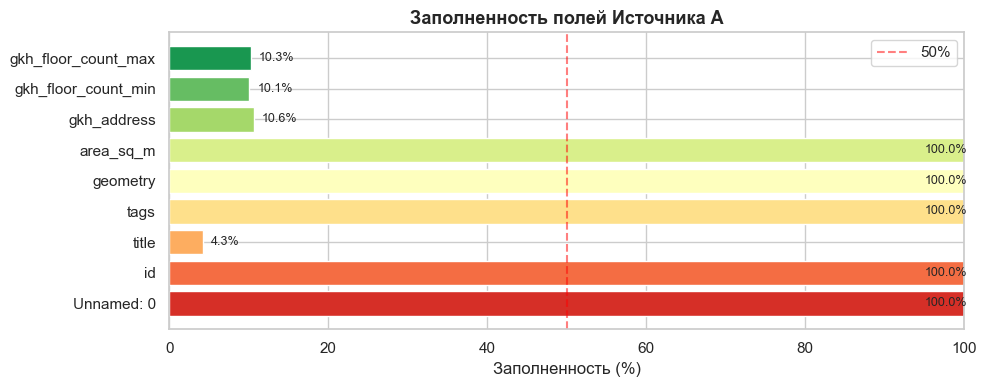

In [9]:
# Визуализация пропусков
fig, ax = plt.subplots(figsize=(10, 4))
cols = df.columns.tolist()
fill_rates = [(1 - df[c].isnull().mean()) * 100 for c in cols]

bars = ax.barh(cols, fill_rates, color=sns.color_palette('RdYlGn', len(cols)))
ax.set_xlim(0, 100)
ax.set_xlabel('Заполненность (%)')
ax.set_title('Заполненность полей Источника А', fontsize=13, fontweight='bold')

for bar, val in zip(bars, fill_rates):
    ax.text(min(val + 1, 95), bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

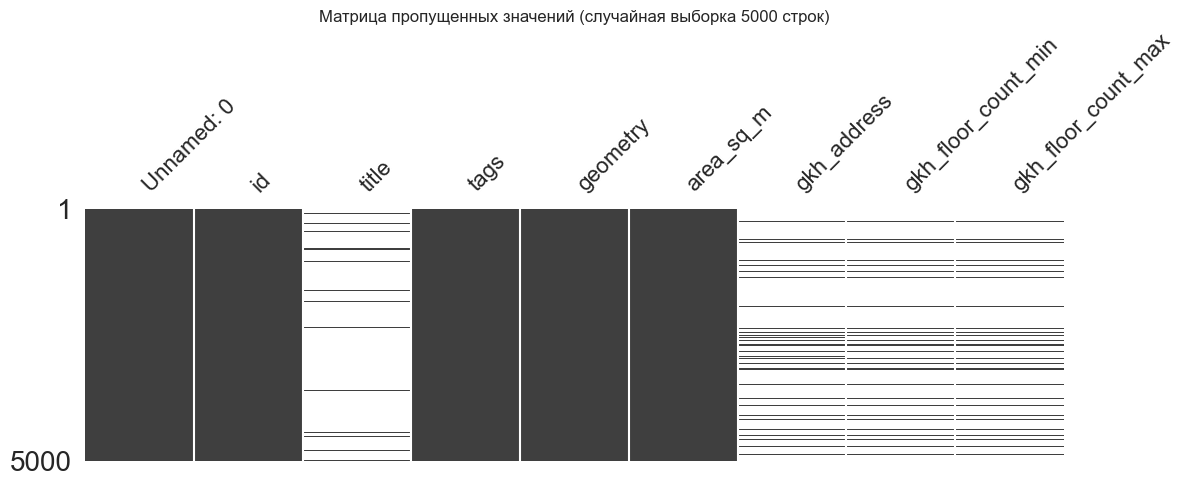

In [10]:
# Матрица пропусков (missingno)
if HAS_MISSINGNO:
    fig, ax = plt.subplots(figsize=(12, 5))
    msno.matrix(df.sample(min(5000, len(df)), random_state=42), ax=ax, sparkline=False)
    ax.set_title('Матрица пропущенных значений (случайная выборка 5000 строк)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Установите missingno для матрицы пропусков: pip install missingno")

In [11]:
# Совместные пропуски: строки, где и адрес, и этажность отсутствует
no_address = df['gkh_address'].isnull()
no_floor   = df['gkh_floor_count_min'].isnull() & df['gkh_floor_count_max'].isnull()
both_missing = no_address & no_floor

print(f"Нет адреса:                   {no_address.sum():,} ({no_address.mean()*100:.1f}%)")
print(f"Нет этажности (min и max):    {no_floor.sum():,} ({no_floor.mean()*100:.1f}%)")
print(f"Нет ни адреса, ни этажности:  {both_missing.sum():,} ({both_missing.mean()*100:.1f}%)")
print(f"\nЭти записи - здания без какой-либо атрибутики из ЖКХ")

Нет адреса:                   153,215 (89.4%)
Нет этажности (min и max):    153,804 (89.7%)
Нет ни адреса, ни этажности:  153,215 (89.4%)

Эти записи - здания без какой-либо атрибутики из ЖКХ


## 3. Анализ тегов - типы объектов

Поле `tags` содержит список типов объектов в виде строки - например `['жилое здание']`. Нужно распарсить его и проанализировать состав.

In [12]:
# Парсинг тегов из строкового представления списка
def parse_tags(val):
    if pd.isna(val):
        return []
    val = str(val).strip()
    # Убираем квадратные скобки и кавычки
    val = val.strip('[]')
    tags = [t.strip().strip("'\"") for t in val.split(',')]
    return [t for t in tags if t]

df['tags_parsed'] = df['tags'].apply(parse_tags)

# Первый тег
df['primary_tag'] = df['tags_parsed'].apply(lambda x: x[0] if x else 'неизвестно')

# Распределение основных тегов
tag_counts = df['primary_tag'].value_counts()
print("Топ тегов:")
print(tag_counts.to_string())

Топ тегов:
primary_tag
жилое здание                            58297
постройка                               48218
промышленность                          22565
Комплекс зданий                          8487
бизнес и услуги                          7768
торговля                                 5326
образование                              3933
офисы                                    1945
медицина                                 1548
культура и отдых                         1518
государство                              1153
детский сад                              1028
религия                                   902
None                                      878
школа                                     791
транспорт                                 763
стилобат                                  636
спорт                                     601
службы и объекты ЖКХ                      588
церковь                                   381
торговый центр                            359
больница   

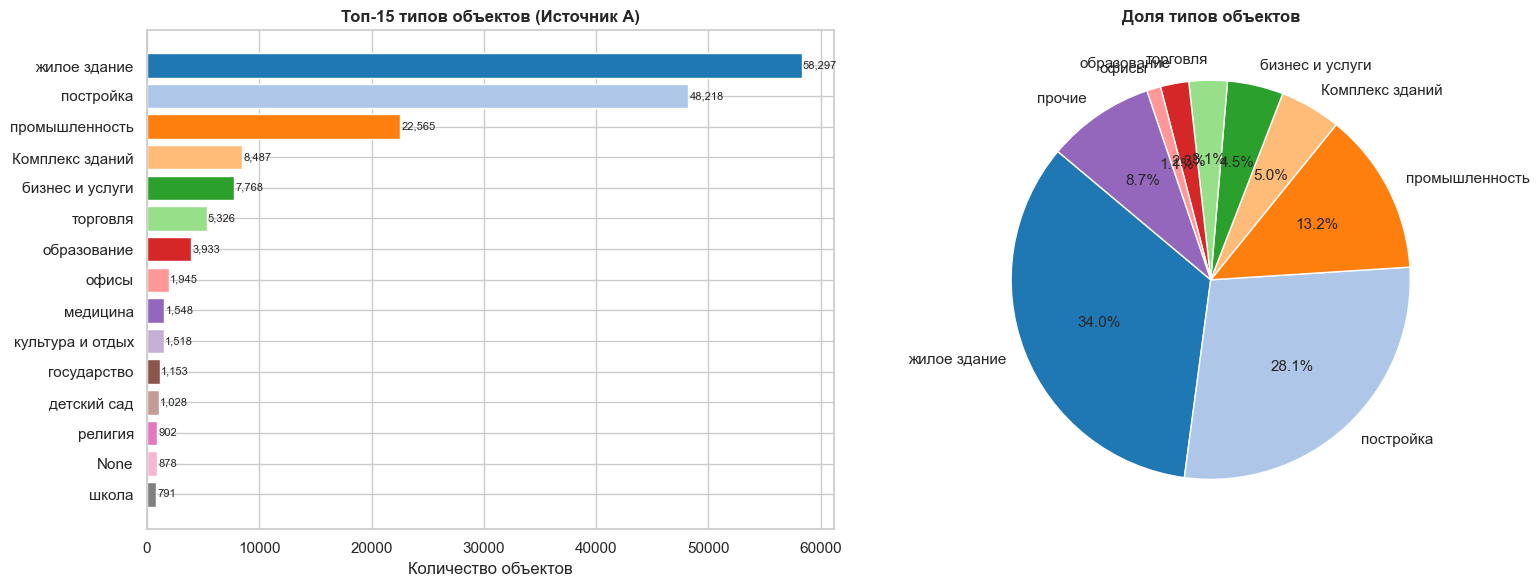

In [13]:
# Визуализация распределения тегов
top_tags = tag_counts.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Горизонтальный бар
colors = sns.color_palette('tab20', len(top_tags))
axes[0].barh(top_tags.index[::-1], top_tags.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Количество объектов')
axes[0].set_title('Топ-15 типов объектов (Источник А)', fontsize=12, fontweight='bold')
for i, (val, name) in enumerate(zip(top_tags.values[::-1], top_tags.index[::-1])):
    axes[0].text(val + 100, i, f'{val:,}', va='center', fontsize=8)

# Pie chart топ-8
top8 = tag_counts.head(8)
other = tag_counts.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({'прочие': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('tab20', len(pie_data)))
axes[1].set_title('Доля типов объектов', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Объекты с несколькими тегами
df['tag_count'] = df['tags_parsed'].apply(len)
print("Распределение количества тегов на объект:")
print(df['tag_count'].value_counts().sort_index())

multi_tag = df[df['tag_count'] > 1]
print(f"\nОбъектов с несколькими тегами: {len(multi_tag):,} ({len(multi_tag)/len(df)*100:.1f}%)")
if len(multi_tag) > 0:
    print("Примеры:")
    print(multi_tag['tags'].head(5).to_string())

Распределение количества тегов на объект:
tag_count
1    106852
2     58584
3      5799
4       214
5         5
Name: count, dtype: int64

Объектов с несколькими тегами: 64,602 (37.7%)
Примеры:
0               ['постройка, сооружение']
1               ['постройка, сооружение']
9               ['постройка, сооружение']
11    ['Комплекс зданий', 'жилое здание']
13    ['Комплекс зданий', 'жилое здание']


In [15]:
# Категоризация тегов: здания vs нездания
BUILDING_TAGS = {
    'жилое здание', 'нежилое здание', 'Комплекс зданий', 'Нежилое здание',
    'Жилое здание', 'жилой дом', 'многоквартирный дом'
}
NON_BUILDING_TAGS = {
    'постройка', 'строение', 'сооружение', 'торговля', 'промышленность',
    'бизнес и услуги', 'культура и отдых', 'образование', 'медицина'
}

def categorize(tag):
    t = str(tag).lower()
    if 'жил' in t:
        return 'Жилое'
    elif 'нежил' in t or 'нежилое' in t:
        return 'Нежилое'
    elif 'комплекс' in t:
        return 'Комплекс'
    elif any(x in t for x in ['постройк', 'сооруж', 'строен']):
        return 'Постройка/сооружение'
    elif any(x in t for x in ['торг', 'промышл', 'бизнес', 'услуг']):
        return 'Коммерческое'
    elif any(x in t for x in ['культур', 'образ', 'медиц', 'спорт']):
        return 'Социальное'
    else:
        return 'Прочее'

df['category'] = df['primary_tag'].apply(categorize)
print("Категории объектов:")
cat_counts = df['category'].value_counts()
for cat, cnt in cat_counts.items():
    print(f"  {cat:<25} {cnt:>7,} ({cnt/len(df)*100:.1f}%)")

Категории объектов:
  Жилое                      58,297 (34.0%)
  Постройка/сооружение       48,218 (28.1%)
  Коммерческое               36,301 (21.2%)
  Прочее                     11,410 (6.7%)
  Социальное                  8,741 (5.1%)
  Комплекс                    8,487 (5.0%)


## 4. Анализ площади - `area_sq_m`

Площадь важный признак для выявления аномалий, например гаражей или сараев, и для предсказания высоты.

In [16]:
# Базовая статистика площади
area = df['area_sq_m'].dropna()
print(f"Всего записей с площадью: {len(area):,}")
print(f"\nСтатистика (м²):")
print(f"  Минимум:      {area.min():>12.2f}")
print(f"  1-й квартиль: {area.quantile(0.25):>12.2f}")
print(f"  Медиана:      {area.median():>12.2f}")
print(f"  Среднее:      {area.mean():>12.2f}")
print(f"  3-й квартиль: {area.quantile(0.75):>12.2f}")
print(f"  99-й перцент: {area.quantile(0.99):>12.2f}")
print(f"  Максимум:     {area.max():>12.2f}")
print(f"  Станд. откл:  {area.std():>12.2f}")

Всего записей с площадью: 171,454

Статистика (м²):
  Минимум:              0.31
  1-й квартиль:        40.00
  Медиана:            118.87
  Среднее:            504.23
  3-й квартиль:       517.67
  99-й перцент:      4824.67
  Максимум:        137682.44
  Станд. откл:       1465.01


In [17]:
# Объекты с нулевой или очень маленькой площадью
zero_area   = (df['area_sq_m'] <= 0).sum()
tiny_area   = ((df['area_sq_m'] > 0) & (df['area_sq_m'] < 5)).sum()
small_area  = ((df['area_sq_m'] >= 5) & (df['area_sq_m'] < 20)).sum()
garage_like = ((df['area_sq_m'] >= 20) & (df['area_sq_m'] < 50)).sum()

print("Распределение по диапазонам площади:")
print(f"  ≤ 0 м²      (нулевые/отрицательные): {zero_area:>7,}")
print(f"  0–5 м²      (мелкие объекты):         {tiny_area:>7,}")
print(f"  5–20 м²     (гаражи/ларьки):          {small_area:>7,}")
print(f"  20–50 м²    (маленькие постройки):    {garage_like:>7,}")
print(f"  50–500 м²:                            {((df['area_sq_m']>=50)&(df['area_sq_m']<500)).sum():>7,}")
print(f"  500–5000 м²:                          {((df['area_sq_m']>=500)&(df['area_sq_m']<5000)).sum():>7,}")
print(f"  > 5000 м²   (крупные здания/кварталы):{(df['area_sq_m']>=5000).sum():>7,}")

Распределение по диапазонам площади:
  ≤ 0 м²      (нулевые/отрицательные):       0
  0–5 м²      (мелкие объекты):           2,783
  5–20 м²     (гаражи/ларьки):           15,085
  20–50 м²    (маленькие постройки):     33,600
  50–500 м²:                             75,995
  500–5000 м²:                           42,376
  > 5000 м²   (крупные здания/кварталы):  1,615


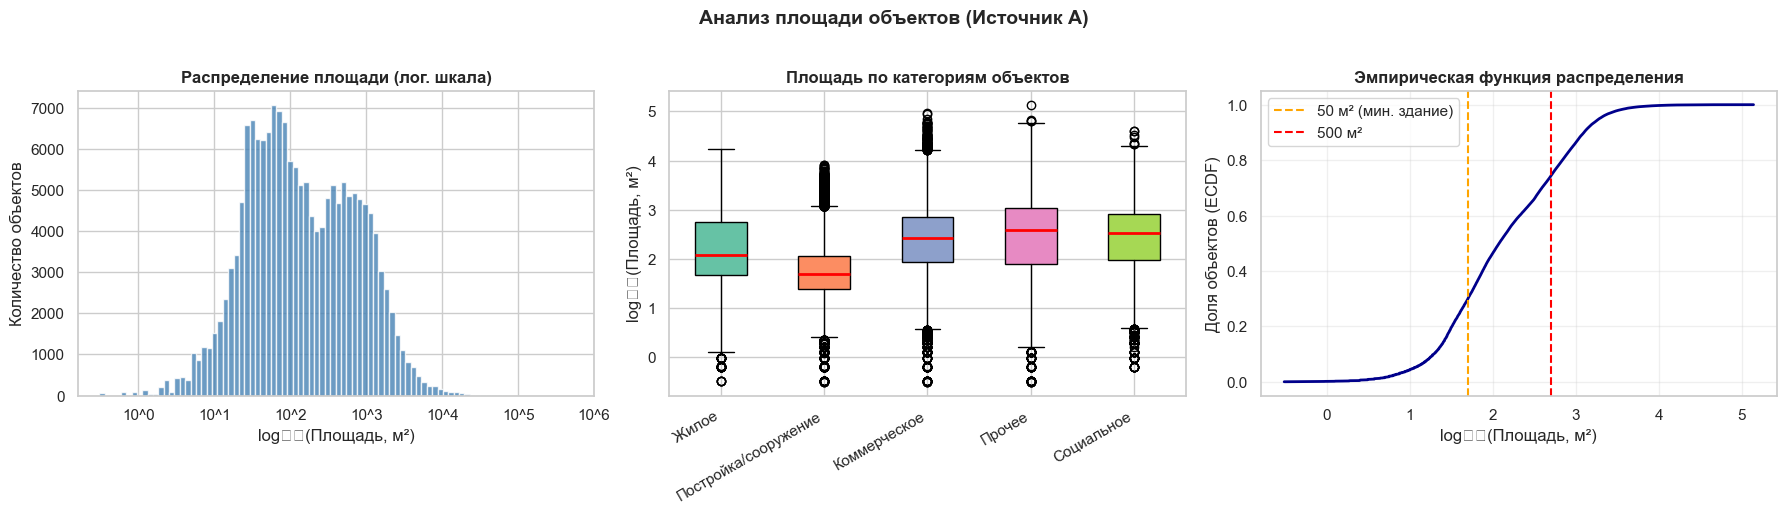

In [18]:
# Визуализация распределения площади
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Логарифмическая гистограмма
log_area = np.log10(area[area > 0])
axes[0].hist(log_area, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('log₁₀(Площадь, м²)')
axes[0].set_ylabel('Количество объектов')
axes[0].set_title('Распределение площади (лог. шкала)', fontweight='bold')
xticks = [0, 1, 2, 3, 4, 5, 6]
axes[0].set_xticks(xticks)
axes[0].set_xticklabels([f'10^{x}' for x in xticks])

# Boxplot по категориям
cats = df[df['area_sq_m'] > 0].copy()
cats['log_area'] = np.log10(cats['area_sq_m'])
top_cats = cats['category'].value_counts().head(5).index
plot_data = [cats[cats['category'] == c]['log_area'].values for c in top_cats]
bp = axes[1].boxplot(plot_data, vert=True, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors_box = sns.color_palette('Set2', len(top_cats))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[1].set_xticklabels(top_cats, rotation=30, ha='right')
axes[1].set_ylabel('log₁₀(Площадь, м²)')
axes[1].set_title('Площадь по категориям объектов', fontweight='bold')

# ECDF
sorted_area = np.sort(area[area > 0])
ecdf = np.arange(1, len(sorted_area)+1) / len(sorted_area)
axes[2].plot(np.log10(sorted_area), ecdf, color='darkblue', lw=2)
axes[2].axvline(np.log10(50), color='orange', linestyle='--', label='50 м² (мин. здание)')
axes[2].axvline(np.log10(500), color='red', linestyle='--', label='500 м²')
axes[2].set_xlabel('log₁₀(Площадь, м²)')
axes[2].set_ylabel('Доля объектов (ECDF)')
axes[2].set_title('Эмпирическая функция распределения', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Анализ площади объектов (Источник А)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Топ самых больших объектов - возможные аномалии
print("🔍 Топ-20 объектов по площади (возможные аномалии):")
display_cols = ['id', 'title', 'primary_tag', 'area_sq_m', 'gkh_address', 'gkh_floor_count_max']
top_area = df.nlargest(20, 'area_sq_m')[display_cols]
top_area['area_sq_m'] = top_area['area_sq_m'].apply(lambda x: f'{x:,.0f}')
print(top_area.to_string(index=False))

🔍 Топ-20 объектов по площади (возможные аномалии):
    id                                       title       primary_tag area_sq_m gkh_address  gkh_floor_count_max
 80831                                         NaN Трёхмерная модель   137,682         NaN                  NaN
114621                                         NaN    промышленность    91,652         NaN                  NaN
132363                                         NaN    промышленность    89,175         NaN                  NaN
167014                                         NaN   Комплекс зданий    73,742         NaN                  NaN
106596                                Питер Радуга    торговый центр    68,794         NaN                  NaN
 31536                               Газпром Арена Трёхмерная модель    67,616         NaN                  NaN
138234                        Цех № 83 РЭП Холдинг              None    64,672         NaN                  NaN
102622                                   СКА Арена   

In [20]:
# Самые маленькие объекты, потенциальный мусор
print("🔍 Топ-20 наименьших объектов (потенциальный мусор):")
small = df[df['area_sq_m'] > 0].nsmallest(20, 'area_sq_m')[display_cols]
small['area_sq_m'] = small['area_sq_m'].apply(lambda x: f'{x:.2f}')
print(small.to_string(index=False))

🔍 Топ-20 наименьших объектов (потенциальный мусор):
    id                      title     primary_tag area_sq_m gkh_address  gkh_floor_count_max
111240                        NaN бизнес и услуги      0.31         NaN                  NaN
 63742 Церковь святого Станислава         церковь      0.31         NaN                  NaN
 82668                        NaN           офисы      0.31         NaN                  NaN
 82734                        NaN       постройка      0.31         NaN                  NaN
 63521 Церковь святого Станислава         церковь      0.31         NaN                  NaN
 83652                        NaN       постройка      0.31         NaN                  NaN
 33516                        NaN  промышленность      0.31         NaN                  NaN
 43724                        NaN       постройка      0.31         NaN                  NaN
110729                        NaN  промышленность      0.31         NaN                  NaN
 63689 Церковь свя

## 5. Анализ адресов (`gkh_address`)

Адреса из «Реформы ЖКХ» присутствуют только у части объектов. Анализируем их структуру, географическое распределение и качество.

In [21]:
addr = df['gkh_address'].dropna()
print(f"Объектов с адресом: {len(addr):,} ({len(addr)/len(df)*100:.1f}%)")
print(f"Уникальных адресов: {addr.nunique():,}")
print(f"Дубликатов адресов: {len(addr) - addr.nunique():,}")

Объектов с адресом: 18,239 (10.6%)
Уникальных адресов: 17,313
Дубликатов адресов: 926


In [22]:
# Анализ структуры адресов
print("Примеры адресов:")
for a in addr.sample(min(10, len(addr)), random_state=42):
    print(f"  '{a}'")

Примеры адресов:
  'г. Санкт-Петербург, пр-кт. Северный, д. 77, к. 3, лит. А'
  'г. Санкт-Петербург, пр-кт. Ветеранов, д. 55, к. А'
  'г. Санкт-Петербург, наб. Канала Грибоедова, д. 27, лит. А'
  'г. Санкт-Петербург, ул. Доблести, д. 7, к. 2'
  'г. Санкт-Петербург, ул. Вавиловых, д. 17, к. 1'
  'г. Санкт-Петербург, наб. Реки Фонтанки, д. 67-69, лит. А'
  'г. Санкт-Петербург, ул. 7-я Советская, д. 10-12 А'
  'г. Санкт-Петербург, пр-кт. Невский, д. 51, лит. А'
  'г. Санкт-Петербург, ул. Таврическая, д. 2 Г'
  'г. Санкт-Петербург, ул. Ораниенбаумская, д. 13, лит. А'


In [23]:
# Извлечение города из адреса
def extract_city(address):
    if pd.isna(address):
        return None
    # Ищем первый компонент до запятой
    parts = str(address).split(',')
    if parts:
        return parts[0].strip()
    return None

df['city_extracted'] = df['gkh_address'].apply(extract_city)
city_counts = df['city_extracted'].value_counts().head(15)
print("Топ городов/субъектов в адресе:")
print(city_counts.to_string())

Топ городов/субъектов в адресе:
city_extracted
г. Санкт-Петербург      18236
обл. Ленинградская          2
д. аллея Поликарпова        1


In [24]:
# Дублирующиеся адреса - несколько полигонов на один адрес (разные корпуса?)
dup_addr = df[df['gkh_address'].notna()].groupby('gkh_address').size()
dup_addr = dup_addr[dup_addr > 1].sort_values(ascending=False)
print(f"Адресов с несколькими полигонами: {len(dup_addr):,}")
print(f"Максимум полигонов на адрес: {dup_addr.max()}")
print(f"\nТоп-10 адресов по числу полигонов:")
for addr_str, cnt in dup_addr.head(10).items():
    print(f"  {cnt:>3}x  {addr_str}")

Адресов с несколькими полигонами: 901
Максимум полигонов на адрес: 4

Топ-10 адресов по числу полигонов:
    4x  г. Санкт-Петербург, пр-кт. Ветеранов, д. 52, к. 1
    4x  г. Санкт-Петербург, пр-кт. Комендантский, д. 27, к. 1
    4x  г. Санкт-Петербург, ул. Итальянская, д. 12А
    4x  г. Санкт-Петербург, ул. Руднева, д. 9, к. 3, лит. А
    3x  г. Санкт-Петербург, пр-кт. Юнтоловский, д. 47, к. 1, стр. 1
    3x  г. Санкт-Петербург, пр-кт. Ленинский, д. 100, к. 3
    3x  г. Санкт-Петербург, ул. 9-я Советская, д. 16
    3x  г. Санкт-Петербург, пр-кт. Просвещения, д. 53, к. 1, стр. Д
    3x  г. Санкт-Петербург, пл. Льва Мациевича, д. 1
    3x  г. Санкт-Петербург, пл. Льва Мациевича, д. 2


## 6. Анализ этажности (`gkh_floor_count_min`, `gkh_floor_count_max`)

Это единственная косвенная информация о высоте в Источнике А. Данные из «Реформы ЖКХ» - усреднённые по всему зданию.

In [25]:
# Базовая статистика этажности
for col in ['gkh_floor_count_min', 'gkh_floor_count_max']:
    non_null = df[col].dropna()
    print(f"\n📊 {col}:")
    print(f"   Заполнено: {len(non_null):,} ({len(non_null)/len(df)*100:.1f}%)")
    if len(non_null) > 0:
        print(f"   Мин: {non_null.min():.0f}   Медиана: {non_null.median():.0f}   Макс: {non_null.max():.0f}   Среднее: {non_null.mean():.1f}")


📊 gkh_floor_count_min:
   Заполнено: 17,293 (10.1%)
   Мин: 0   Медиана: 5   Макс: 34   Среднее: 6.3

📊 gkh_floor_count_max:
   Заполнено: 17,632 (10.3%)
   Мин: 0   Медиана: 5   Макс: 36   Среднее: 7.3


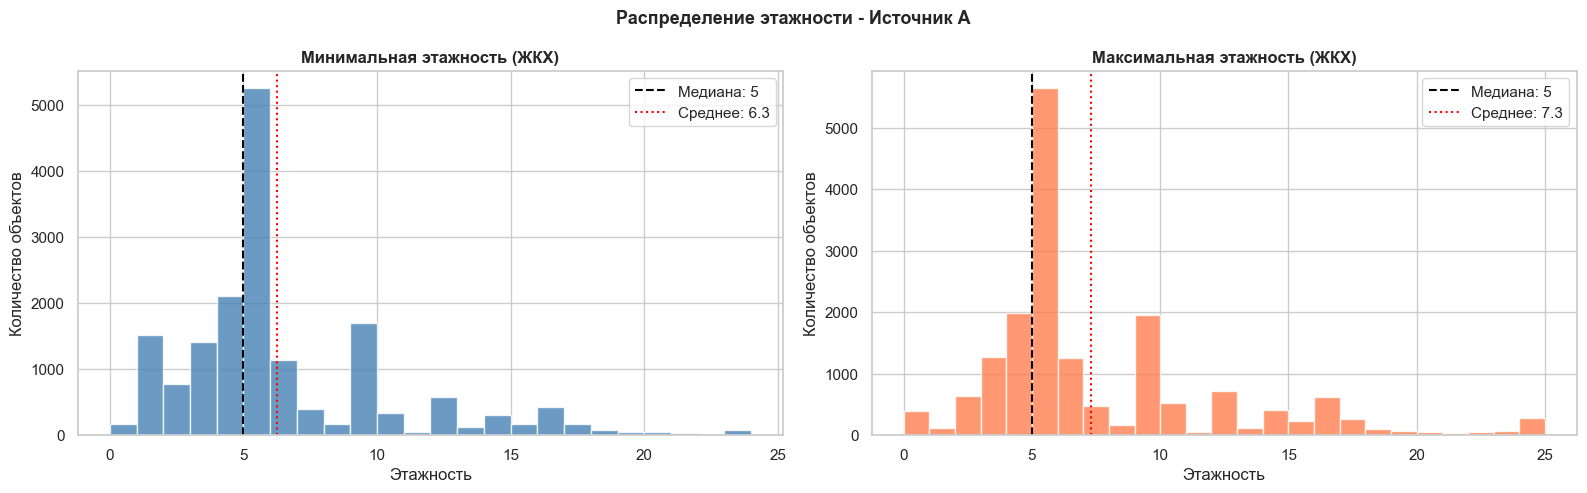

In [26]:
# Распределение этажности
floor_data = df[['gkh_floor_count_min', 'gkh_floor_count_max']].dropna(how='all')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, color in zip(axes, ['gkh_floor_count_min', 'gkh_floor_count_max'], ['steelblue', 'coral']):
    vals = df[col].dropna()
    if len(vals) == 0:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        continue
    # Обрезаем выбросы для визуализации
    clip_max = vals.quantile(0.99)
    vals_clipped = vals[vals <= clip_max]
    
    ax.hist(vals_clipped, bins=min(int(clip_max), 50), color=color, edgecolor='white', alpha=0.8)
    ax.axvline(vals.median(), color='black', linestyle='--', label=f'Медиана: {vals.median():.0f}')
    ax.axvline(vals.mean(), color='red', linestyle=':', label=f'Среднее: {vals.mean():.1f}')
    ax.set_xlabel('Этажность')
    ax.set_ylabel('Количество объектов')
    label = 'Минимальная' if 'min' in col else 'Максимальная'
    ax.set_title(f'{label} этажность (ЖКХ)', fontweight='bold')
    ax.legend()

plt.suptitle('Распределение этажности - Источник А', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Аномальные значения этажности
for col in ['gkh_floor_count_min', 'gkh_floor_count_max']:
    vals = df[col].dropna()
    if len(vals) == 0:
        continue
    anomalies_high = vals[vals > 100]
    anomalies_zero = vals[vals <= 0]
    print(f"\n{col}:")
    print(f"  Значений > 100 этажей: {len(anomalies_high):,}")
    if len(anomalies_high) > 0:
        print(f"  Максимальные аномалии: {sorted(anomalies_high.values, reverse=True)[:10]}")
    print(f"  Значений ≤ 0 этажей:   {len(anomalies_zero):,}")


gkh_floor_count_min:
  Значений > 100 этажей: 0
  Значений ≤ 0 этажей:   167

gkh_floor_count_max:
  Значений > 100 этажей: 0
  Значений ≤ 0 этажей:   388


In [28]:
# Расхождение min и max этажности
both_floors = df[['gkh_floor_count_min', 'gkh_floor_count_max']].dropna()
if len(both_floors) > 0:
    both_floors = both_floors.copy()
    both_floors['diff'] = both_floors['gkh_floor_count_max'] - both_floors['gkh_floor_count_min']
    
    print(f"Объектов с обеими значениями этажности: {len(both_floors):,}")
    print(f"Объектов где min > max (ошибка): {(both_floors['diff'] < 0).sum():,}")
    print(f"Объектов где min == max (однородные): {(both_floors['diff'] == 0).sum():,} ({(both_floors['diff']==0).mean()*100:.1f}%)")
    print(f"Объектов с разницей > 5 этажей: {(both_floors['diff'] > 5).sum():,}")
    print(f"\nСтатистика разницы (max - min):")
    print(both_floors['diff'].describe())

Объектов с обеими значениями этажности: 17,275
Объектов где min > max (ошибка): 420
Объектов где min == max (однородные): 13,499 (78.1%)
Объектов с разницей > 5 этажей: 1,333

Статистика разницы (max - min):
count    17275.000000
mean         1.035369
std          3.557882
min        -28.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         28.000000
Name: diff, dtype: float64


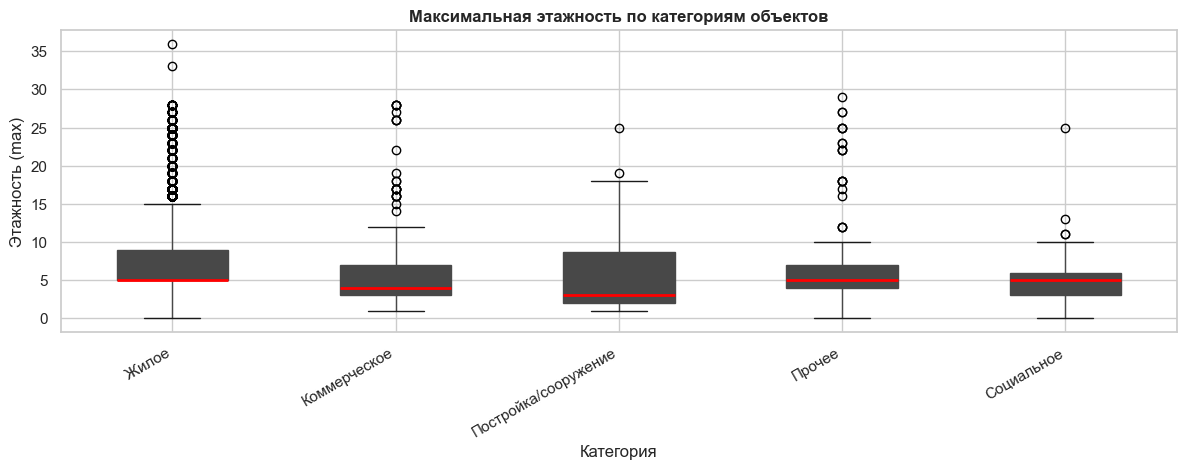

In [29]:
# Этажность по типу объекта
if df['gkh_floor_count_max'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    top_cats = df['category'].value_counts().head(5).index
    plot_df = df[df['category'].isin(top_cats) & df['gkh_floor_count_max'].notna()]
    plot_df = plot_df[plot_df['gkh_floor_count_max'] <= 50]  # убираем аномалии
    
    if len(plot_df) > 0:
        plot_df.boxplot(column='gkh_floor_count_max', by='category', ax=ax,
                        patch_artist=True, medianprops=dict(color='red', linewidth=2))
        ax.set_title('Максимальная этажность по категориям объектов', fontweight='bold')
        ax.set_xlabel('Категория')
        ax.set_ylabel('Этажность (max)')
        plt.suptitle('')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

## 7. Анализ геометрии

Геометрия хранится в формате WKT. Анализ:
- Типы геометрий - Polygon vs MultiPolygon
- Валидность полигонов
- Соответствие `area_sq_m` и реальной площади WKT
- Аномалии координат

In [30]:
# Парсинг геометрии
print("Парсинг WKT геометрий...")

def safe_wkt_load(wkt_str):
    try:
        return wkt.loads(str(wkt_str))
    except Exception:
        return None

df['geometry_parsed'] = df['geometry'].apply(safe_wkt_load)

null_geom  = df['geometry_parsed'].isnull().sum()
valid_geom = df['geometry_parsed'].notna().sum()
print(f"✅ Успешно распарсено: {valid_geom:,}")
print(f"❌ Ошибки парсинга:    {null_geom:,} ({null_geom/len(df)*100:.2f}%)")

Парсинг WKT геометрий...
✅ Успешно распарсено: 171,454
❌ Ошибки парсинга:    0 (0.00%)


Типы геометрий:
  Polygon              171,173 (99.8%)
  MultiPolygon             281 (0.2%)


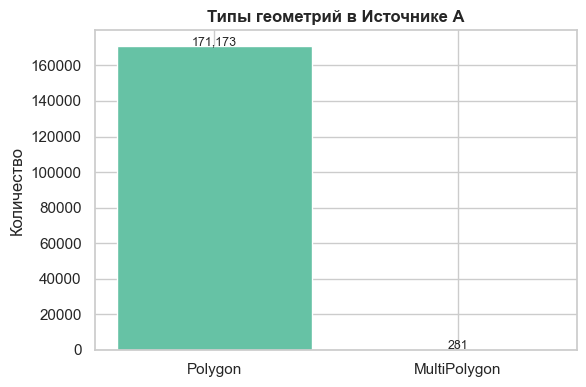

In [31]:
# Типы геометрий
geom_types = df['geometry_parsed'].dropna().apply(lambda g: g.geom_type).value_counts()
print("Типы геометрий:")
for gtype, cnt in geom_types.items():
    print(f"  {gtype:<20} {cnt:>7,} ({cnt/valid_geom*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(geom_types.index, geom_types.values, color=sns.color_palette('Set2', len(geom_types)))
ax.set_title('Типы геометрий в Источнике А', fontweight='bold')
ax.set_ylabel('Количество')
for i, v in enumerate(geom_types.values):
    ax.text(i, v + 10, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
# Проверка валидности геометрий
print("Проверка валидности геометрий (может занять некоторое время)...")

geom_subset = df['geometry_parsed'].dropna()

# Для больших датасетов можно делать выборку
SAMPLE_SIZE = min(10000, len(geom_subset))
geom_sample = geom_subset.sample(SAMPLE_SIZE, random_state=42)

validity = geom_sample.apply(lambda g: g.is_valid)
invalid_count = (~validity).sum()

print(f"\nВыборка: {SAMPLE_SIZE:,} объектов")
print(f"  Валидных:   {validity.sum():,} ({validity.mean()*100:.1f}%)")
print(f"  Невалидных: {invalid_count:,} ({invalid_count/SAMPLE_SIZE*100:.1f}%)")

# Примеры причин невалидности
if invalid_count > 0:
    invalid_geoms = geom_sample[~validity].head(10)
    print(f"\nПримеры причин невалидности:")
    for g in invalid_geoms:
        print(f"  {explain_validity(g)}")

Проверка валидности геометрий (может занять некоторое время)...

Выборка: 10,000 объектов
  Валидных:   10,000 (100.0%)
  Невалидных: 0 (0.0%)


In [33]:
# Проверка нулевых площадей геометрий
def get_geom_area(g):
    try:
        return g.area if g is not None else None
    except:
        return None

geom_areas = df['geometry_parsed'].apply(get_geom_area)
zero_geom_area = (geom_areas == 0).sum()
tiny_geom_area = ((geom_areas > 0) & (geom_areas < 1e-10)).sum()

print(f"Геометрий с нулевой площадью: {zero_geom_area:,}")
print(f"Геометрий с площадью < 1e-10: {tiny_geom_area:,}")
print("(Примечание: WKT может быть в градусах, поэтому area в WGS84 будет в °², а не м²)")

Геометрий с нулевой площадью: 0
Геометрий с площадью < 1e-10: 102
(Примечание: WKT может быть в градусах, поэтому area в WGS84 будет в °², а не м²)


In [34]:
# Анализ координат (bounding box всего датасета)
def get_centroid(g):
    try:
        c = g.centroid
        return c.x, c.y
    except:
        return None, None

print("Вычисление центроидов (выборка 5000)...")
sample_geoms = df['geometry_parsed'].dropna().sample(min(5000, valid_geom), random_state=42)
centroids = sample_geoms.apply(get_centroid)
cx = [c[0] for c in centroids if c[0] is not None]
cy = [c[1] for c in centroids if c[1] is not None]

if cx and cy:
    print(f"Диапазон X (долгота): {min(cx):.4f} — {max(cx):.4f}")
    print(f"Диапазон Y (широта):  {min(cy):.4f} — {max(cy):.4f}")
    
    # Санкт-Петербург примерно: 59.8–60.1°N, 29.7–30.7°E
    out_of_spb = sum(1 for x, y in zip(cx, cy)
                     if not (29.0 <= x <= 31.5 and 59.5 <= y <= 60.5))
    print(f"\nОбъектов вне bbox Санкт-Петербурга: {out_of_spb} ({out_of_spb/len(cx)*100:.1f}%)")

Вычисление центроидов (выборка 5000)...
Диапазон X (долгота): 30.0641 — 30.5577
Диапазон Y (широта):  59.6933 — 60.0876

Объектов вне bbox Санкт-Петербурга: 0 (0.0%)


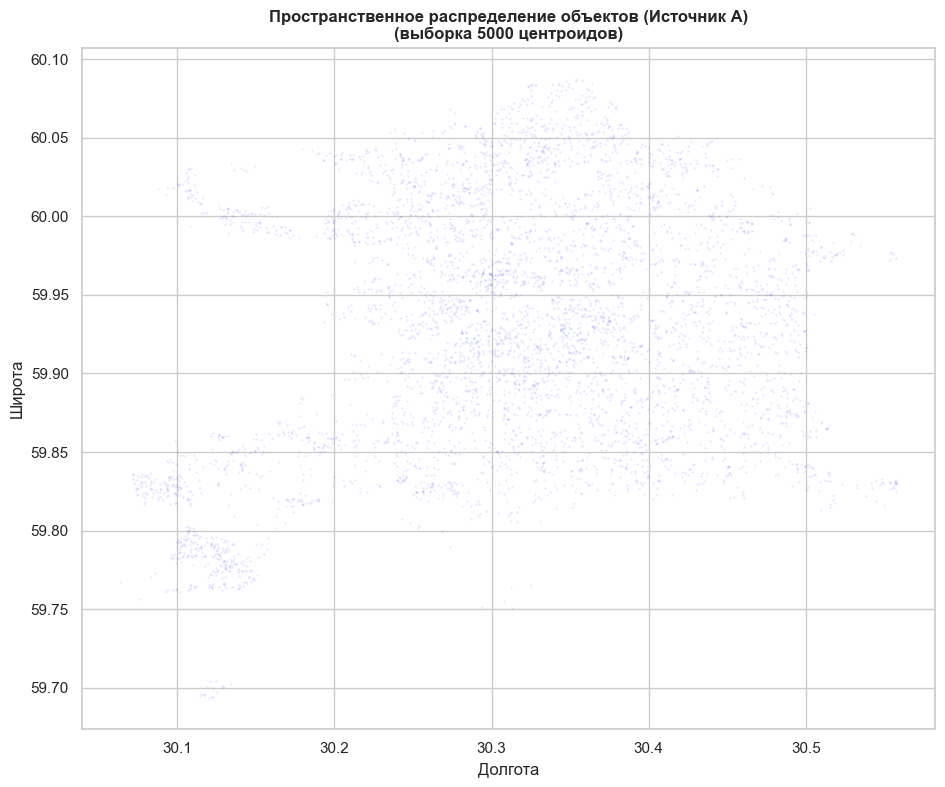

In [35]:
# Scatter plot центроидов (пространственное распределение)
if cx and cy:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(cx, cy, alpha=0.05, s=1, color='blue')
    ax.set_xlabel('Долгота')
    ax.set_ylabel('Широта')
    ax.set_title('Пространственное распределение объектов (Источник А)\n(выборка 5000 центроидов)',
                 fontweight='bold')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

In [36]:
# MultiPolygon: количество частей
multi_geoms = df[df['geometry_parsed'].apply(
    lambda g: g is not None and g.geom_type == 'MultiPolygon'
)]

if len(multi_geoms) > 0:
    parts_count = multi_geoms['geometry_parsed'].apply(lambda g: len(list(g.geoms)))
    print(f"MultiPolygon объектов: {len(multi_geoms):,}")
    print(f"Среднее число частей: {parts_count.mean():.1f}")
    print(f"Максимум частей:      {parts_count.max()}")
    print("\nРаспределение числа частей:")
    print(parts_count.value_counts().sort_index().head(10))

MultiPolygon объектов: 281
Среднее число частей: 2.3
Максимум частей:      10

Распределение числа частей:
geometry_parsed
2     239
3      23
4      11
5       2
6       3
7       2
10      1
Name: count, dtype: int64


## 8. Анализ дубликатов

Проверка наличия полных дубликатов и объектов с одинаковыми геометриями.

In [37]:
# Безопасный поиск дубликатов
df_for_dups = df.copy()

for col in df_for_dups.columns:
    df_for_dups[col] = df_for_dups[col].apply(
        lambda x: tuple(x) if isinstance(x, list) else x
    )

# Полные дубликаты строк
full_dups = df_for_dups.duplicated().sum()
print(f"Полных дубликатов строк: {full_dups:,}")

# Дубликаты по id
id_dups = df_for_dups['id'].duplicated().sum()
print(f"Дубликатов по 'id':      {id_dups:,}")

# Дубликаты по геометрии
geom_dups = df_for_dups['geometry'].duplicated().sum()
print(f"Дубликатов по геометрии: {geom_dups:,} ({geom_dups/len(df_for_dups)*100:.2f}%)")

Полных дубликатов строк: 0
Дубликатов по 'id':      0
Дубликатов по геометрии: 0 (0.00%)


In [38]:
# Дубликаты по геометрии + площади
geom_area_dups = df.duplicated(subset=['geometry', 'area_sq_m']).sum()
print(f"Дубликатов по (геометрия + площадь): {geom_area_dups:,}")

# Примеры дублирующихся геометрий
if geom_dups > 0:
    dup_geom = df[df['geometry'].duplicated(keep=False)].sort_values('geometry')
    print(f"\nПримеры объектов с одинаковой геометрией:")
    print(dup_geom.head(6)[['id', 'title', 'primary_tag', 'area_sq_m', 'geometry']].to_string())

Дубликатов по (геометрия + площадь): 0


## 9. Корреляционный анализ

Анализ связей между числовыми переменными.

Строк с полными числовыми данными: 17,275


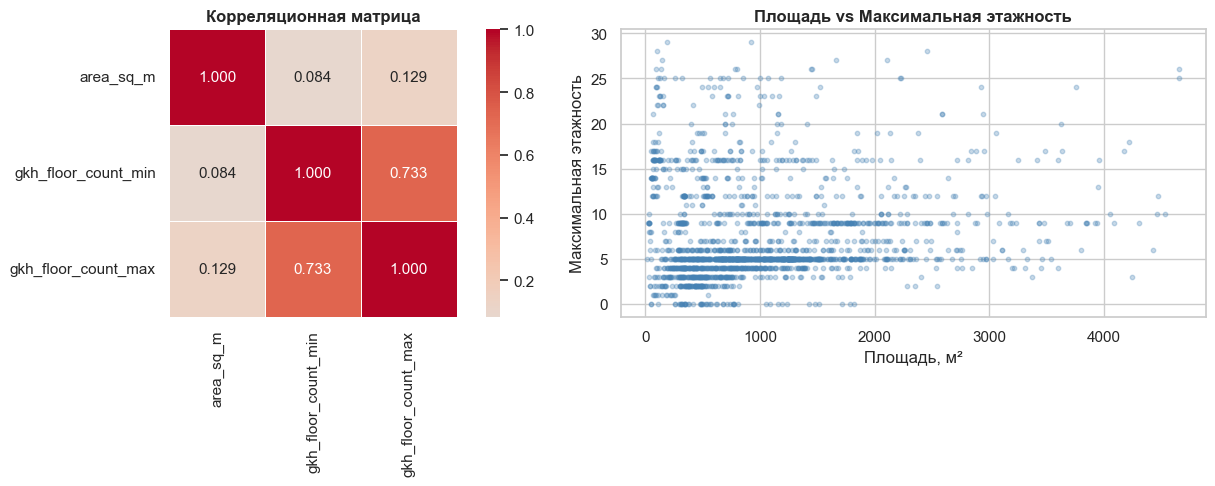

In [39]:
# Числовые колонки
num_cols = ['area_sq_m', 'gkh_floor_count_min', 'gkh_floor_count_max']
num_df = df[num_cols].dropna()

print(f"Строк с полными числовыми данными: {len(num_df):,}")

if len(num_df) > 10:
    # Корреляционная матрица
    corr = num_df.corr()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                ax=axes[0], square=True, linewidths=0.5)
    axes[0].set_title('Корреляционная матрица', fontweight='bold')
    
    # Scatter: площадь vs этажность
    sample = num_df.sample(min(2000, len(num_df)), random_state=42)
    # Убираем аномалии для визуализации
    s = sample[(sample['area_sq_m'] < sample['area_sq_m'].quantile(0.99)) &
               (sample['gkh_floor_count_max'] < 50)]
    
    axes[1].scatter(s['area_sq_m'], s['gkh_floor_count_max'],
                    alpha=0.3, s=10, color='steelblue')
    axes[1].set_xlabel('Площадь, м²')
    axes[1].set_ylabel('Максимальная этажность')
    axes[1].set_title('Площадь vs Максимальная этажность', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

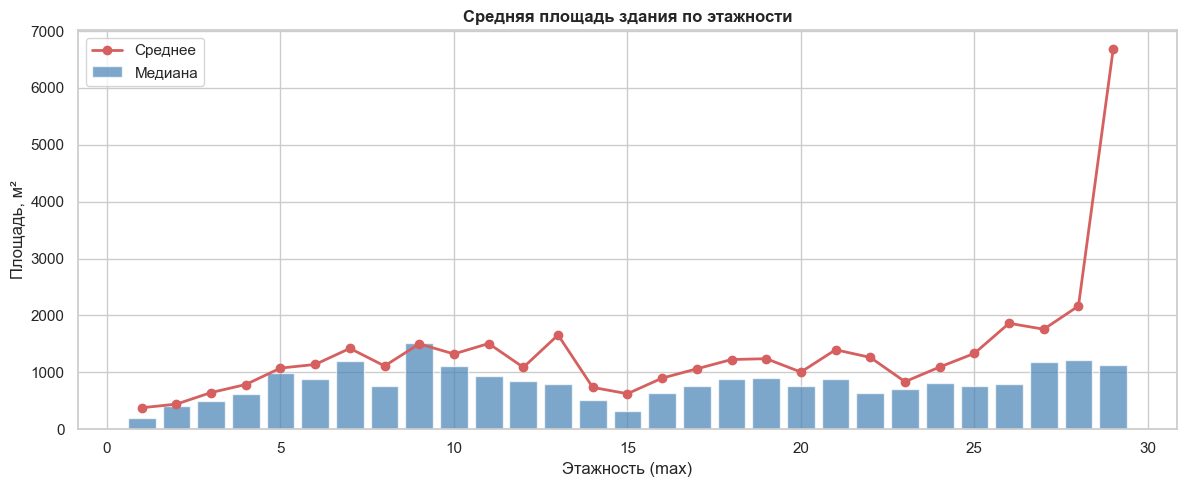

In [40]:
# Средняя площадь по этажности (для строений с известной этажностью)
if len(num_df) > 0:
    floors_df = df[df['gkh_floor_count_max'].notna() & 
                   (df['gkh_floor_count_max'] > 0) & 
                   (df['gkh_floor_count_max'] <= 30)].copy()
    
    if len(floors_df) > 0:
        avg_area_by_floor = floors_df.groupby('gkh_floor_count_max')['area_sq_m'].agg(['mean', 'median', 'count'])
        avg_area_by_floor.columns = ['Средняя площадь', 'Медианная площадь', 'Кол-во']
        
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(avg_area_by_floor.index, avg_area_by_floor['Медианная площадь'],
               color='steelblue', alpha=0.7, label='Медиана')
        ax.plot(avg_area_by_floor.index, avg_area_by_floor['Средняя площадь'],
                'ro-', linewidth=2, markersize=6, label='Среднее')
        ax.set_xlabel('Этажность (max)')
        ax.set_ylabel('Площадь, м²')
        ax.set_title('Средняя площадь здания по этажности', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()

## 10. Сводная карточка качества данных

Итоговый отчёт по качеству для принятия решения об очистке.

In [41]:
total = len(df)

hashable_cols = [
    c for c in df.columns
    if not df[c].apply(lambda x: isinstance(x, list)).any()
]

quality_report = {
    'Всего записей': total,
    'Полных дубликатов': df[hashable_cols].duplicated().sum(),
    'Дубликатов по геометрии': df['geometry'].duplicated().sum(),
    'Нет геометрии (null/ошибка)': df['geometry_parsed'].isnull().sum(),
    'Нулевая площадь (≤ 0)': (df['area_sq_m'] <= 0).sum(),
    'Мелкие объекты (< 10 м²)': (df['area_sq_m'] < 10).sum(),
    'Нет адреса ЖКХ': df['gkh_address'].isnull().sum(),
    'Нет этажности (min)': df['gkh_floor_count_min'].isnull().sum(),
    'Нет этажности (max)': df['gkh_floor_count_max'].isnull().sum(),
    'Аномальная этажность > 100': (df['gkh_floor_count_max'].fillna(0) > 100).sum(),
    'min > max этажность': (
        (df['gkh_floor_count_min'] > df['gkh_floor_count_max'])
        .fillna(False).sum()
    ),
}

print("="*60)
print("     СВОДНАЯ КАРТОЧКА КАЧЕСТВА — ИСТОЧНИК А")
print("="*60)
for k, v in quality_report.items():
    pct = f"({v/total*100:.1f}%)" if k != 'Всего записей' else ''
    status = '✅' if v == 0 else ('⚠️' if v/total < 0.05 else '❌')
    if k == 'Всего записей':
        status = '📊'
    print(f"  {status}  {k:<40} {v:>7,} {pct}")
print("="*60)

     СВОДНАЯ КАРТОЧКА КАЧЕСТВА — ИСТОЧНИК А
  📊  Всего записей                            171,454 
  ✅  Полных дубликатов                              0 (0.0%)
  ✅  Дубликатов по геометрии                        0 (0.0%)
  ✅  Нет геометрии (null/ошибка)                    0 (0.0%)
  ✅  Нулевая площадь (≤ 0)                          0 (0.0%)
  ⚠️  Мелкие объекты (< 10 м²)                   7,649 (4.5%)
  ❌  Нет адреса ЖКХ                           153,215 (89.4%)
  ❌  Нет этажности (min)                      154,161 (89.9%)
  ❌  Нет этажности (max)                      153,822 (89.7%)
  ✅  Аномальная этажность > 100                     0 (0.0%)
  ⚠️  min > max этажность                          420 (0.2%)


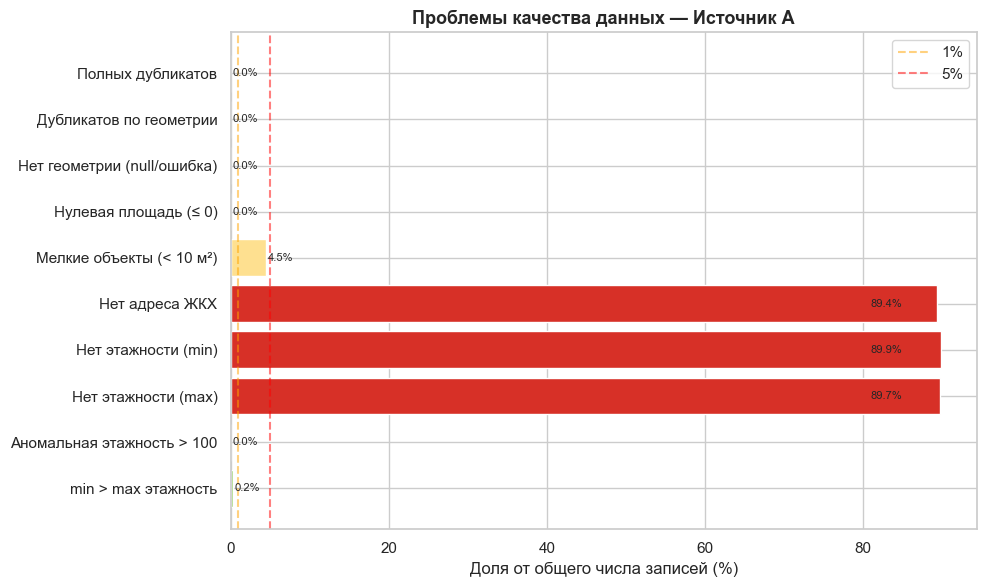

In [42]:
# Визуальная карточка качества
issues = {
    k: v for k, v in quality_report.items() if k != 'Всего записей'
}

fig, ax = plt.subplots(figsize=(10, 6))
keys = list(issues.keys())
vals = [v / total * 100 for v in issues.values()]

colors = ['#d73027' if v > 5 else '#fee090' if v > 1 else '#91cf60' for v in vals]
bars = ax.barh(keys[::-1], vals[::-1], color=colors[::-1])

ax.set_xlabel('Доля от общего числа записей (%)')
ax.set_title('Проблемы качества данных — Источник А', fontsize=13, fontweight='bold')
ax.axvline(1, color='orange', linestyle='--', alpha=0.5, label='1%')
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5%')

for bar, val in zip(bars, vals[::-1]):
    ax.text(min(val + 0.3, max(vals)*0.9), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()